In [ ]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list

%load_ext autoreload 
%autoreload 2

In [4]:
msa_dir_path = '../data/genes/mmseqs/'

def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs/'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}


# Cluster analysis: **cluster_25**

Based on Foldseek results, cluster_25 is a group of ssDNA-binding proteins.Analysis of the metatranscriptomic data indicates that the cluster_25 protein on bz_0 is expressed in large quantities concomitantly with cluster_20 in 2025 samples. Therefore, if Betazoids do engage in a viral-like life cycle, it is likely that these proteins play an important role. 


"Surprisingly, gene 5 produces an intracellular protein in an amount comparable to the amount of the major coat protein, the product of gene 8, and the p5 protein is necessary for phage production purified this p5 protein and showed that it binds to single-stranded DNA. The p5 protein is present in the infected cell in a complex with phage circular single-stranded DNA, in an elongated intracellular nucleoprotein complex." [[Marvin et. al. 2014](https://www.sciencedirect.com/science/article/abs/pii/S0079610714000066)]

In [5]:
cluster_id = 25

In [6]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[(genes_df.cluster_id == cluster_id)].copy()

# Write the protein sequences to a FASTA file and create an MSA. 
msa_path = f'../data/genes/cluster_{cluster_id}.afa'
FASTAFile.from_df(genes_df).write(f'../data/genes/cluster_{cluster_id}.faa')
if not os.path.exists(msa_path):
    subprocess.run(f'muscle -align ../data/genes/cluster_{cluster_id}.faa -output {msa_path}', shell=True, check=True)
msa = MSAFile.from_file(msa_path)

print('Number of genes:', len(genes_df))
print('Maximum length:', genes_df.seq.apply(len).max())
print('Minimum length:', genes_df.seq.apply(len).min())

print()
print(str(FASTAFile.from_df(genes_df)))

Number of genes: 3
Maximum length: 144
Minimum length: 139

>orfm.bz_0.1_70
MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPDGKGGKFDKLNWNFDIDGKKIISQSSTTISNLSKAFGWIKALTGKEPEIGKDFSPSSVNGKSCQVIIKHRAVVLNTETVQMPYVSDVLPVKKSK
>orfm.bz_2.1_138
MTENQEIENFQVDVKESKPFEYPEIDDGEYNAILKKVTLKAGIENKQHEKFDLMTWYFDVDGKEIKGTSSAKITTMSKAYGWIKSITGIEPEINKPFIPSSLKDSKCRIIVKNEDEVRDFQGTKTTMHKPIVIEVMHTKTKK
>orfm.bz_11.1_159
MKYKMTENKEPMKNFTIGITESKKFEIPEIKDGVYDAVLKDMELKVGLPDGKGGAFDMIQWNFDVDGKEIAGKTSTIISTLSKAYIWITALTGAEPEKDKDFQPVSVMGNKCQVIIKHQKKIREFNHERQTLNLPYIHDVLPAK



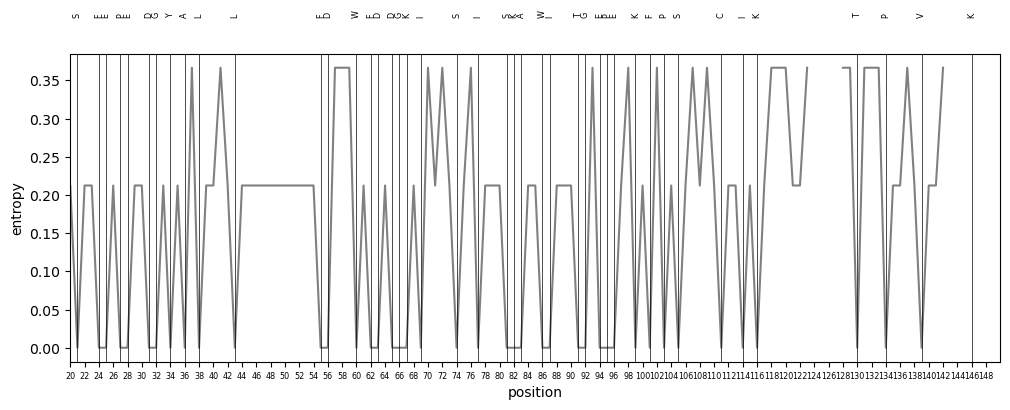

In [112]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_entropy(msa, ax=ax, annotate=True, x_max=150)
plt.show()

If cluster_25 proteins are indeed analagous to p5 proteins of filamentous phages, we would expect them to be present in all Betazoid genomes. It is possible that the sequence-based clustering was unable to capture divergent homologs, and these proteins are more conserved than preliminary analysis indicates. To address this, we searched each Betazoid genome for genes matching the following criteria:

1. The length of the full protein is shorter than 180 residues. 

2. The length of the full protein is greater than 110 residues. 

3. The protein has some Foldseek hit to a (non-HTH) single-stranded DNA binding protein. 

4. **Supported by Prodigal predictions.** It seems as though essentially all of the annotated genes are predicted by Prodigal, and wading through all OrfM candidates is somewhat intractable.

5. Not assigned to a gene cluster which is already characterized.

After this preliminary filtering step, we identified another conserved cluster (cluster_12) with 6 members, 5 of which were included in the filter. Inspection of the Foldseek hits, predicted structures, and genomic location indicates that this cluster is likely homologous to cluster_25. 

After the search process described above, only genome bz_7 lacked a cluster_25 protein. We then manually-inspected all predicted structures for proteins of approximately the right length and genomic location, and identified orfm.bz_7.1_37 (length 212 aa), whose N-terminal predicted structure resembles an OB-like fold (with very low confidence). However, the C terminus is partly within the bz_7 repeat region, and therefore folds into a coil-like structure. We then manually cleaved the 94 terminal residues and re-folded, producing a high-confidence structure which is clearly homologous to other cluster_25 proteins. The long C-terminal tail is likely an artifact caused by a genome assembly error.

*It is worth noting here that many of the cluster_5 homologs with Foldseek hits to ssDNA have alignment TM scores lower than 0.5, despite having reasonable alignment lengths. It is unclear if his is due to problems with the AlphaFold prediction, or due to the fact that the fold itself is distinct. However, based on this observation, it seems that applying more lenient TM score cutoffs for some Betazoid proteins may be justified when trying to assign a function.*

In [82]:
include_terms = ['DUF669', 'ssDNA', 'OB-fold', 'single-stranded', 'single stranded', 'gene V', 'OB fold']
exclude_terms = ['Winged helix', 'HTH', 'Bacteriophage T5 Orf172', '8j86-assembly1_A'] # These terms yield false positives; OB-folds are very different from HTH. 

foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*')])
foldseek_search_df['genome_id'] = foldseek_search_df.query_id.apply(get_genome_id)

filters = dict()
# Removed the tm_score threshold after realizing it was filtering out hits to other cluster_12 proteins. 
# filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 50
filters['bz_12_gene'] = foldseek_search_df.genome_id == 'bz_12'
filters['not_ssdna_binding'] = ~foldseek_search_df.target_header.str.contains( '|'.join(include_terms), case=False) | foldseek_search_df.target_header.str.contains( '|'.join(exclude_terms), case=False)

foldseek_search_df = apply_filters(filters, foldseek_search_df)
foldseek_search_gene_ids = foldseek_search_df.query_id.unique()

print('\nNumber of genomes with a potential ssDNA-binding protein:', foldseek_search_df.genome_id.nunique())
print('Number of genes with potential ssDNA-binding activity:', len(foldseek_search_gene_ids))

apply_filters: 79859 entries removed by short_alignment.
apply_filters: 41792 entries removed by bz_12_gene.
apply_filters: 709051 entries removed by not_ssdna_binding.

Number of genomes with a potential ssDNA-binding protein: 11
Number of genes with potential ssDNA-binding activity: 159


In [128]:
candidate_genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
candidate_genes_df['cluster_id'] = candidate_genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))

filters = dict()
filters['no_ssdna_binding_hit'] = ~candidate_genes_df.index.isin(foldseek_search_gene_ids)
filters['longer_than_200_aa'] = (candidate_genes_df.length_from_start_codon > 200)
filters['shorter_than_110_aa'] = (candidate_genes_df.length_from_start_codon < 110) # The filamentous phage equivalent is 97 aa.
filters['cluster_already_characterized'] = candidate_genes_df.cluster_id.isin([0, 1, 7, 3, 8, 20, 2, 4])
filters['not_supported_by_prodigal'] = candidate_genes_df.prodigal_gene_id.isnull()

exclude_gene_ids = ['orfm.bz_11.1_179'] # Weak hits, and bz_11 already has a cluster_25 protein.
exclude_gene_ids += ['orfm.bz_11.1_43'] # Weak hits, and bz_11 already has a cluster_25 protein.
exclude_gene_ids += ['orfm.bz_11.1_173'] # Weak hits, and bz_11 already has a cluster_25 protein.
exclude_gene_ids += ['orfm.bz_11.1_45'] # Weak hits, and bz_11 already has a cluster_25 protein.
exclude_gene_ids += ['orfm.bz_10.1_72'] # Foldseek hits indicate Ig-like fold.
exclude_gene_ids += ['orfm.bz_9.1_111'] # Foldseek hits indicate Ig-like fold.
exclude_gene_ids += ['orfm.bz_7.1_95'] # None of the ssDNA binding hits are for proteins that make sense; probably has some nucleotide-binding activity. 
exclude_gene_ids += ['orfm.bz_7.1_44'] # Very high-confidence structure that looks completely wrong, no convincing ssDNA-binding Foldseek hits.
exclude_gene_ids += ['orfm.bz_7.1_149'] # Structure and Foldseek hits do not make sense. 
exclude_gene_ids += ['orfm.bz_4.1_174'] # Too short and the structure looks wrong. 
exclude_gene_ids += ['orfm.bz_7.1_170'] # Structure looks wrong, only one ssDNA-binding hit to non-OB fold protein B2LXS7.
exclude_gene_ids += ['orfm.bz_8.1_75'] # The matching hits are to exonucleases complexed with ssDNA, and structure is wrong. 
exclude_gene_ids += ['orfm.bz_9.1_94'] # Structure looks wrong, no real Foldseek hits.
exclude_gene_ids += ['orfm.bz_10.1_151'] # bz_10 already has a cluster_12 protein, structure looks wrong. 
filters['manually_removed'] = candidate_genes_df.index.isin(exclude_gene_ids)

cluster_12_gene_ids = ['orfm.bz_1.1_30', 'orfm.bz_3.1_155', 'orfm.bz_5.1_42', 'orfm.bz_8.1_87', 'orfm.bz_9.1_158', 'orfm.bz_10.1_120']
cluster_25_gene_ids = ['orfm.bz_0.1_70', 'orfm.bz_2.1_138', 'orfm.bz_11.1_159']

candidate_gene_ids = apply_filters(filters, candidate_genes_df).index.tolist()
candidate_gene_ids += ['orfm.bz_8.1_87']
candidate_gene_ids += ['orfm.bz_7.1_37']

assert np.all(np.isin(cluster_12_gene_ids, candidate_gene_ids)), 'Some cluster_12 genes are missing from the final list.'
assert np.all(np.isin(cluster_25_gene_ids, candidate_gene_ids)), 'Some cluster_25 genes are missing from the final list.'

apply_filters: 1474 entries removed by no_ssdna_binding_hit.
apply_filters: 85 entries removed by longer_than_200_aa.
apply_filters: 1455 entries removed by shorter_than_110_aa.
apply_filters: 76 entries removed by cluster_already_characterized.
apply_filters: 1204 entries removed by not_supported_by_prodigal.
apply_filters: 14 entries removed by manually_removed.


In [129]:
genes_df = candidate_genes_df.loc[candidate_gene_ids].copy()

# Remove the C-terminal repeat region of orfm.bz_7.1_37. Based on the new length (118 aa), it is likely that the C-terminus 
# is at least partially missing. 
repeat_region = 'GADLTDADLTDADLTGANLTDADIRHVNLTDAVLTGAVLTGADLRYANLTDADLTDADLTDADFTGANLTDADLRYAYHTDTQKKQAEINEGRF'
genes_df.loc['orfm.bz_7.1_37', 'seq'] = genes_df.loc['orfm.bz_7.1_37', 'seq'].replace(repeat_region, '')
print('New length of gene orfm.bz_7.1_37:', len(genes_df.loc['orfm.bz_7.1_37', 'seq']))

print('\nNumber of genes:', len(genes_df))
print('Maximum length:', genes_df.seq.apply(len).max())
print('Minimum length:', genes_df.seq.apply(len).min())

print()
print(str(FASTAFile.from_df(genes_df)))

New length of gene orfm.bz_7.1_37: 118

Number of genes: 11
Maximum length: 158
Minimum length: 118

>orfm.bz_0.1_70
MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPDGKGGKFDKLNWNFDIDGKKIISQSSTTISNLSKAFGWIKALTGKEPEIGKDFSPSSVNGKSCQVIIKHRAVVLNTETVQMPYVSDVLPVKKSK
>orfm.bz_1.1_30
MSEKENKVEYAKIDESDEKDVQEKLNASKTLYPQWKGDTKGQTITGYVKEILTFKDLNGKDKHGVLVNLQTKNDAYPVVSIWANTVILSGLKRIAEGQNFMSFETMTESLKTIEGKTIALRYEGEEKSSQKGFKPYMNYTVVEI
>orfm.bz_2.1_138
MTENQEIENFQVDVKESKPFEYPEIDDGEYNAILKKVTLKAGIENKQHEKFDLMTWYFDVDGKEIKGTSSAKITTMSKAYGWIKSITGIEPEINKPFIPSSLKDSKCRIIVKNEDEVRDFQGTKTTMHKPIVIEVMHTKTKK
>orfm.bz_3.1_155
MTEKEITYANIDESADKEIQDKLNEAKIQYPIWKGETKGQTITGYVKEVLTFKDLNGSNKHGVLLNLQTKSEEYPIITVWANTVILSGIKRMAILQNFLSFEAMTESLKTIEGKFIAIRYEGKEKSSQKGYKDYDNYTVVEI
>orfm.bz_4.1_35
VFKIINIKNKTGEKNMVNIADMYSGEYLNVERLKELKLVDKVLIIVGTSTETIQEKEKLVVVLEGVEELFVPNKTNAYLIADKLGNESTNWRGAGIKLGLTKVMLNGKMTPSMIVKEVIEKPTV
>orfm.bz_5.1_42
LNKMKENTTVSGTDKETVNASSFLFNDDSMQEKLNNQLVIYPVLKFTEKGQTIKGLVIDVINYPNMNEGKGSILVNLNTLNKDIPIVTFWLNTVAQSQMFKVLGI

To validate this final set of cluster_25 candidates, we examined (1) genome position, (2) pairwise sequence identity, and (3) structural similarity.

In [ ]:
alphafold_input_dir = f'../data/genes/alphafold/af_input/cluster_{cluster_id}'
alphafold_output_dir = f'../data/genes/alphafold/af_output/cluster_{cluster_id}' 
os.makedirs(alphafold_input_dir, exist_ok=True)

# Configure the AlphaFold3 job, using fewer diffusion samples and recycles to reduce runtime. 
alphafold_params = dict()
alphafold_params['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
alphafold_params['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime.

for row in genes_df.itertuples():
    input = AlphaFoldInputFile(row.Index, dialect='alphafold3', num_seeds=3, version=2) # Use 3 seeds rather than the default 5 to reduce runtime.  
    input.add_seq(row.seq, paired_msa=None, unpaired_msa=None) # Opted to use the AlphaFold-generated MSAs, as the structure predictions are already high-confidence.
    input.write(os.path.join(alphafold_input_dir, f'{row.Index}.json'))

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(alphafold_input_dir)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output/{os.path.basename(alphafold_input_dir)}/']
cmd += [f'{param} {value}' for param, value in alphafold_params.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

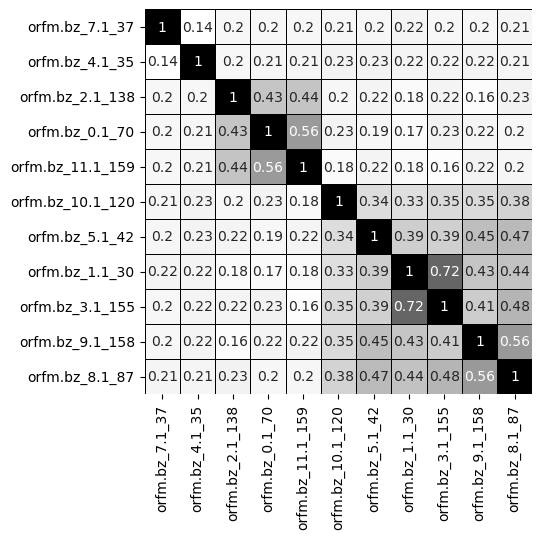

In [134]:
figure_df = get_pairwise_alignments(genes_df.seq, metric='identities', normalize=True)
figure_df[figure_df == 0] = 1 # Fill the diagonals with 1 to make a true similarity matrix. 

z = linkage(squareform(1 - figure_df.values))
order = leaves_list(z)
figure_df = figure_df.iloc[order, order].copy()

min_alignment_length = 110
alignment_lengths =  get_pairwise_alignments(genes_df.seq, metric='aligned', normalize=False).values
alignment_lengths = alignment_lengths[np.triu_indices(len(alignment_lengths), k=1)].ravel()
assert alignment_lengths.min() > min_alignment_length, f'Some of the pairwise alignments failed, minimum alignment length is {alignment_lengths.min()}.'

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(figure_df, cmap='Grays', annot=True, cbar=False, linewidth=0.5, linecolor='black')
ax.set_ylabel('')
ax.set_xlabel('')
plt.show()

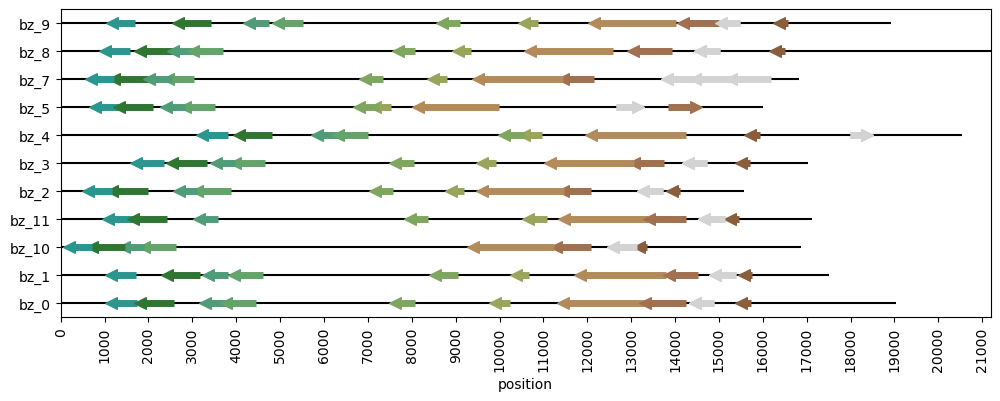

In [130]:
cluster_ids = genes_df.cluster_id.values.tolist() + [8, 7, 0, 4, 5, 6, 1, 3, 2]

colors = ['#8A5E3B', '#A0704F', '#B38A5A', '#9AA45A', '#7FA65E', '#62A46A', '#4F9D78', "#2F7632", "#2B968E", "#5691D8", "#323986"]

palette = dict(zip([8, 7, 0, 4, 5, 6, 1, 3, 2], colors))

fig, ax = plt.subplots(figsize=(12, 4))

figure_df = genes_df.copy()
figure_df = pd.concat([figure_df, pd.read_csv('../data/genes/genes.csv', index_col=0)])
figure_df['cluster_id'] = figure_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
figure_df['gene_id'] = figure_df.index
figure_df = figure_df[figure_df.cluster_id.isin(cluster_ids)].copy()

plot_orfs(figure_df, ax=ax, palette=palette)

## Oligomerization 

The pairwise protein-protein interaction data indicates that cluster_25 proteins interact with themselves.



In [3]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[(genes_df.cluster_id == 25)].copy()
genes_df['gc_content'] = genes_df.nt_seq.apply(get_gc_content)

FASTAFile.from_df(genes_df).write('../data/genes/cluster_25.faa')
if not os.path.exists('../data/genes/cluster_25.afa'):
    subprocess.run('muscle -align ../data/genes/cluster_25.faa -output ../data/genes/cluster_25.afa', shell=True, check=True)

msa = MSAFile.from_file('../data/genes/cluster_25.afa')

for row in genes_df.itertuples():
    print(f'{row.Index} ({row.start}-{row.stop}) {row.gc_content * 100:.1f}% GC {row.seq}')

print('\nMinimum cluster_25 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_25 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_70 (14445-14882) 35.3% GC MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPDGKGGKFDKLNWNFDIDGKKIISQSSTTISNLSKAFGWIKALTGKEPEIGKDFSPSSVNGKSCQVIIKHRAVVLNTETVQMPYVSDVLPVKKSK
orfm.bz_2.1_138 (13260-13719) 30.0% GC MTENQEIENFQVDVKESKPFEYPEIDDGEYNAILKKVTLKAGIENKQHEKFDLMTWYFDVDGKEIKGTSSAKITTMSKAYGWIKSITGIEPEINKPFIPSSLKDSKCRIIVKNEDEVRDFQGTKTTMHKPIVIEVMHTKTKK
orfm.bz_11.1_159 (14663-15131) 33.3% GC MKYKMTENKEPMKNFTIGITESKKFEIPEIKDGVYDAVLKDMELKVGLPDGKGGAFDMIQWNFDVDGKEIAGKTSTIISTLSKAYIWITALTGAEPEKDKDFQPVSVMGNKCQVIIKHQKKIREFNHERQTLNLPYIHDVLPAK

Minimum cluster_25 gene length: 139
Maximum cluster_25 gene length: 144


Number of genomes with a potential ssDNA-binding protein: 11


In [ ]:
# Write the processed sequences to a FASTA file for alignment. 
# Also generate MSAs in the correct format for AlphaFold.
msa_paths = msa_main(database_path, query_gene_ids=df.index.tolist(), fmt='a3m', name=name, database_dir='../data/genes/mmseqs/db/', output_dir='../data/genes/mmseqs', min_coverage=0.5, sensitivity=10)

msa_dereplicate: min_coverage = 0.9
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 10 representative sequences when clustered at 0.95 minimum identity.
msa_build_afa: muscle -align /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_25_reps.faa -output /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_25.afa
msa_build_afa: clipkit /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_25.afa -o /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_25.trimmed.afa -g 0.8 --log
msa_dereplicate: min_coverage = 0.4
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 10 representative sequences when clustered at 0.95 minimum identity.
msa_build_a3m: num_iterations = 1
msa_build_a3m: sensitivity = 10
msa_build_a3m: mmseqs createdb ../data/genes/mmseqs/cluster_25_reps.faa ../data/genes/mmseqs/db/database
msa_build_a3m: mmseqs search ../data/gen

In [157]:
num_subunits = 1

inputs = list()
for path in msa_paths:
    with open(path, 'r') as f:
        msa = f.read()
        print(f'Number of sequences in {path}:', msa.count('>'))

        gene_id = os.path.basename(path).replace('.a3m', '')
        input = AlphaFoldInputFile(name=f'{get_genome_id(gene_id)}_cluster_20_{num_subunits}mer_processed', num_seeds=1, dialect='alphafoldserver')
        input.add_seq(database_df.loc[gene_id, 'seq'], unpaired_msa=msa, paired_msa="", n=num_subunits)
        inputs.append(input)

inputs = [input.get_info() for input in inputs]
with open('/home/prichter/Downloads/cluster_25.json', 'w') as f:
    json.dump(inputs, f)

Number of sequences in ../data/genes/mmseqs/orfm.bz_0.1_70.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_11.1_159.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_5.1_42.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_2.1_138.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_4.1_35.a3m: 1
Number of sequences in ../data/genes/mmseqs/orfm.bz_10.1_120.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_3.1_155.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_9.1_158.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_8.1_87.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_1.1_30.a3m: 6


In [3]:
colabfold_metadata_df = pd.read_csv('analysis-1-structs_colabfold_metadata.csv')
colabfold_metadata_df = colabfold_metadata_df[colabfold_metadata_df.name.isin(genes_df.index)].copy()
# colabfold_metadata_df
# The pTMs for this cluster are already quite good, so I don't think an MSA is necessary. 

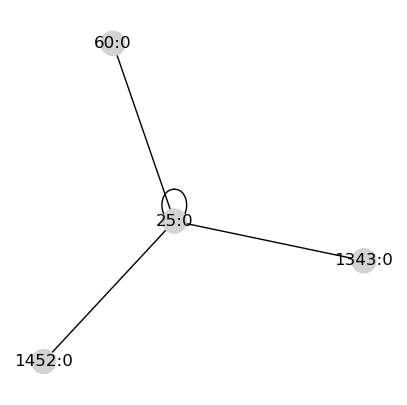

In [4]:
# First, I want to check for any potential contacts in the bz_0 genome. Interestingly, it seems as though the strongest interaction signal is homodimerization. 

contacts_df = pd.read_csv('analysis-1-ppi-bz_0_contacts.csv')
contacts_df = contacts_df[contacts_df.name.str.contains('bz_0.1_70')].copy()
contacts_df = contacts_df.sort_values('contact_prob', ascending=False).drop_duplicates('name')
contacts_df['gene_id_0'] = contacts_df.name.str.split('-').str[0]
contacts_df['gene_id_1'] = contacts_df.name.str.split('-').str[1]
contacts_df['cluster_id_0'] = contacts_df.gene_id_0.map(json.load(open('../data/genes/clusters.json', 'r')))
contacts_df['cluster_id_1'] = contacts_df.gene_id_1.map(json.load(open('../data/genes/clusters.json', 'r')))
contacts_df = contacts_df[(contacts_df.cluster_id_0 == 25) | (contacts_df.cluster_id_1 == 25)].copy()

def get_contact_id(row):
    '''Construct a contact_id from a contact_df entry. These IDs are of the form {node_type}:{position}. The contact IDs are necessarily order-invariant; 
    in other words, the contact ID for an edge (u, v) must be the same ad the contact ID for (v, u).'''
    contact_id = sorted([f'{int(row.cluster_id_0)}:0', f'{int(row.cluster_id_1)}:0'])
    return '-'.join(contact_id)

contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)

fig, ax = plt.subplots(figsize=(5, 5))
graph = get_contact_graph(contacts_df, min_num_models=0, min_contact_prob=0)
plot_contact_graph(graph, pos=nx.spring_layout(graph, k=0.3), ax=ax)



In [5]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]

filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
filters['short_alignment'] = foldseek_search_df.alignment_length < 50

foldseek_search_df = apply_filters(filters, foldseek_search_df)


apply_filters: 7440 entries removed by low_tm_score.
apply_filters: 62 entries removed by short_alignment.


In [6]:
uncharacterized_ids = ['A0A8S5V5T3', 'A0A482MGF2', 'D6PGE1', 'A0A8S5LCJ6', 'A0A5Q2W7C5', 'A0A6J5S277']

categories = dict()
categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized', case=False) | foldseek_search_df.target_header.isin(uncharacterized_ids)
categories['DUF669 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF669') 
categories['DUF5666 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF5666') # https://www.ncbi.nlm.nih.gov/Structure/cdd/pfam18914, OB-like fold, which is involved in DNA binding.
categories['DNA-binding protein'] = foldseek_search_df.target_header.str.contains('DNA-binding|ssDNA binding|single stranded', case=False)
categories['phage-associated protein'] = foldseek_search_df.target_header.str.contains('phage-associated|phage associated|phage protein|phage-related', case=False)

categories = list(zip(*list(categories.items())))

foldseek_search_df['category'] = np.select(condlist=categories[-1], choicelist=categories[0], default='none')
